# Stitching redesign vs. the previous pipeline

Previous pipeline (2026-07-30 .. 08-13): old cached edges (biased, see step
1), affine fitted on absolute coordinates (`camera_rotation.fit_camera_rotation`),
and per-FOV least squares with the nominal grid as the only fallback
(`fit_global_positions`). Here each is reproduced on the same data and
judged by an **image** metric independent of any measurement: the Pearson
correlation of the real bead pixels in every overlap, at each method's
positions. The calculation section reads the live experiment once.

In [1]:
import os, sys, json, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# notebooks/tests/<subfolder>/ is three levels under the repo root.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))
sys.path.insert(0, os.getcwd())
import stitching_redesign_lib as L

NOTEBOOK_NAME = "stitching_redesign_step_06_vs_previous"
# Local data copy shared by every stitching_redesign_step_NN notebook
# (written by step 01; source: BC555_sample_05/epi, cells round).
DATA_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "stitching_redesign" / "data"
FIG_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "explanation" / "figures" / NOTEBOOK_NAME
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS = 14, 12, 11, 10
plt.rcParams.update({"axes.titlesize": TITLE_FS, "axes.labelsize": LABEL_FS,
                     "xtick.labelsize": TICK_FS, "ytick.labelsize": TICK_FS,
                     "legend.fontsize": LEGEND_FS})
DIR_COLORS = {"right": "#1f77b4", "left": "#ff7f0e", "up": "#2ca02c", "down": "#d62728"}


def save(fig, stem):
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight")
    print("saved", path.relative_to(MERCI_DIR))


In [2]:
geom = json.loads((DATA_DIR / "geometry.json").read_text())
PX, STEP, FRAME = geom["pixel_um"], geom["step_um"], geom["frame_px"]
nominal = np.loadtxt(DATA_DIR / "positions.txt", delimiter=",")
NBHD = np.array(geom["neighbourhood"])          # 3x3 FOV ids, row 0 = top
new_df = pd.read_csv(DATA_DIR / "edges_remeasured.csv")
edges = L.Edges(new_df, nominal)
print(f"{len(nominal)} FOVs, {len(new_df)} edges, pixel {PX} um, step {STEP:.3f} um, "
      f"3x3 centre FOV {NBHD[1, 1]}")


476 FOVs, 894 edges, pixel 0.109 um, step 199.066 um, 3x3 centre FOV 221


In [3]:
def draw_edges(ax, P, idx, values, cmap, vmin, vmax, lw=2.0):
    """Segments between FOV centres for edges idx, coloured by values."""
    half = FRAME * PX / 2
    seg = np.stack([P[edges.i[idx]] + half, P[edges.j[idx]] + half], axis=1)
    lc = LineCollection(seg, cmap=cmap, linewidths=lw)
    lc.set_array(np.asarray(values)); lc.set_clim(vmin, vmax)
    ax.add_collection(lc)
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")
    return lc


def mark_nbhd(ax, P, color="k"):
    """Outline the 3x3 neighbourhood on a whole-grid plot."""
    ids = NBHD.ravel()
    x0, y0 = P[ids, 0].min(), P[ids, 1].min()
    x1, y1 = P[ids, 0].max() + FRAME * PX, P[ids, 1].max() + FRAME * PX
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=color, lw=2, ls="--"))


def draw_boxes(ax, P, color, lw=0.6, alpha=1.0):
    for p in P:
        ax.add_patch(mpatches.Rectangle(p, FRAME * PX, FRAME * PX, fill=False, ec=color, lw=lw, alpha=alpha))
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")


In [4]:
nb = np.load(DATA_DIR / "neighbourhood_frames.npz")
BEADS = {int(f): nb[f"beads_{f}"] for f in NBHD.ravel()}
DAPI = {int(f): nb[f"dapi_{f}"] for f in NBHD.ravel()}
PARITY = {int(NBHD[r, c]): (r + c) % 2 for r in range(3) for c in range(3)}
CTR = int(NBHD[1, 1])


def corner_views(position_sets, frames=BEADS, half_um=12.0):
    """Render the 4 corners of the centre FOV (where 4 tiles overlap) for
    each position set. Positions are re-referenced to the centre FOV so
    every panel shows the same place."""
    corners = {"up_left": (0, 1), "up_right": (1, 1), "down_left": (0, 0), "down_right": (1, 0)}
    fig, axes = plt.subplots(len(position_sets), 4, figsize=(16, 4.1 * len(position_sets)), squeeze=False)
    for r, (name, P) in enumerate(position_sets.items()):
        Q = P - P[CTR] + nominal[CTR]
        for c, (cname, (sx, sy)) in enumerate(corners.items()):
            # corner of the centre tile's overlap with its neighbours
            cx = nominal[CTR, 0] + (STEP + (FRAME * PX - STEP) / 2 if sx else (FRAME * PX - STEP) / 2)
            cy = nominal[CTR, 1] + (STEP + (FRAME * PX - STEP) / 2 if sy else (FRAME * PX - STEP) / 2)
            rgb, ext = L.render_tiles(frames, {f: (*Q[f], PARITY[f]) for f in frames}, PX,
                                      bounds=(cx - half_um, cy - half_um, cx + half_um, cy + half_um))
            ax = axes[r, c]
            ax.imshow(rgb, extent=ext, origin="lower", interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(cname)
            if c == 0:
                ax.set_ylabel(name, fontsize=LABEL_FS + 2)
    return fig


In [5]:
keep = np.load(DATA_DIR / "keep.npy"); kidx = np.where(keep)[0]
A = np.load(DATA_DIR / "A.npy")
P_final = np.loadtxt(DATA_DIR / "positions_final.txt", delimiter=",")
old_df = pd.read_csv(DATA_DIR / "old_correspondences.csv")
oe = L.Edges(old_df, nominal)
okeep = L.reject_outliers(oe); ok = np.where(okeep)[0]
M_old = L.fit_old_affine(oe, ok, nominal)
A_on_old = L.fit_displacement_affine(oe, ok)
methods = {
    "nominal": nominal,
    "old: absolute affine (old edges)": L.apply_affine(M_old, nominal),
    "old: per-FOV LSQ (old edges)": L.solve_positions(oe, ok, nominal, np.eye(2), 1e-3, STEP),
    "displacement affine (old edges)": L.apply_affine(A_on_old, nominal),
    "new: displacement affine": L.apply_affine(A, nominal),
    "new: final": P_final,
}
for name, Mx in [("old absolute affine", M_old), ("displacement affine, old edges", A_on_old), ("new A", A)]:
    rot, sv = L.rotation_and_scale(Mx)
    print(f"{name:32s}: rotation {rot:+.4f} deg, singular values {sv[0]:.5f}/{sv[1]:.5f}")

old absolute affine             : rotation -0.0073 deg, singular values 1.00010/0.99998
displacement affine, old edges  : rotation -0.9442 deg, singular values 1.00598/1.00466
new A                           : rotation -0.9455 deg, singular values 1.01521/1.01385


## Calculation: image overlap Pearson for every grid edge, every method (cached)

In [6]:
SOURCE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
from MERci.common.io import read_image_frames
from MERci.acquisition.configs import apply_microscope_orientation
from MERci.acquisition.merlin_config import load_microscope_parameters
mp = load_microscope_parameters("MF3")
ORIENT = {k: bool(mp[k]) for k in ("transpose", "flip_horizontal", "flip_vertical")}
out_csv = DATA_DIR / "image_pearson_by_method.csv"
if out_csv.exists():
    img = pd.read_csv(out_csv)
else:
    order = np.argsort(edges.i, kind="stable")
    cache, rows, t0 = {}, [], time.time()
    def bead(f):
        if f not in cache:
            raw = read_image_frames(SOURCE_DIR / f"data/cells/hal-mf3-cells_{f:03d}.zarr", [0],
                                    frame_width=FRAME, frame_height=FRAME)[0]
            cache[f] = apply_microscope_orientation(raw, **ORIENT)
        return cache[f]
    for n, k in enumerate(order):
        a, b = edges.i[k], edges.j[k]
        row = dict(edge=k, anchor_fov=a, neighbor_fov=b)
        for name, Pm in methods.items():
            ox, oy = np.round((Pm[b] - Pm[a]) / PX).astype(int)
            row[name] = L.band_correlation(bead(a), bead(b), ox, oy)
        rows.append(row)
        for f in list(cache):
            if f < a - 40:
                del cache[f]      # bound memory: FOV ids are ~column-ordered
        if (n + 1) % 150 == 0 or n + 1 == len(order):
            el = time.time() - t0
            print(f"  {n + 1}/{len(order)} edges, {el:.0f}s, ETA {el / (n + 1) * (len(order) - n - 1):.0f}s")
    img = pd.DataFrame(rows).sort_values("edge").reset_index(drop=True)
    img.to_csv(out_csv, index=False)
summary = pd.DataFrame({m: dict(median=img[m].median(), mean=img[m].mean(),
                                frac_gt_0p5=(img[m] > 0.5).mean()) for m in methods}).T.round(3)
print(summary)

  150/894 edges, 16s, ETA 77s


  300/894 edges, 28s, ETA 56s


  450/894 edges, 39s, ETA 38s


  600/894 edges, 47s, ETA 23s


  750/894 edges, 56s, ETA 11s


  894/894 edges, 63s, ETA 0s
                                  median   mean  frac_gt_0p5
nominal                            0.043  0.053        0.002
old: absolute affine (old edges)   0.043  0.053        0.002
old: per-FOV LSQ (old edges)       0.057  0.070        0.003
displacement affine (old edges)    0.055  0.071        0.007
new: displacement affine           0.212  0.321        0.332
new: final                         0.754  0.748        0.999


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_06_vs_previous/nbhd_corners_old_vs_new.png


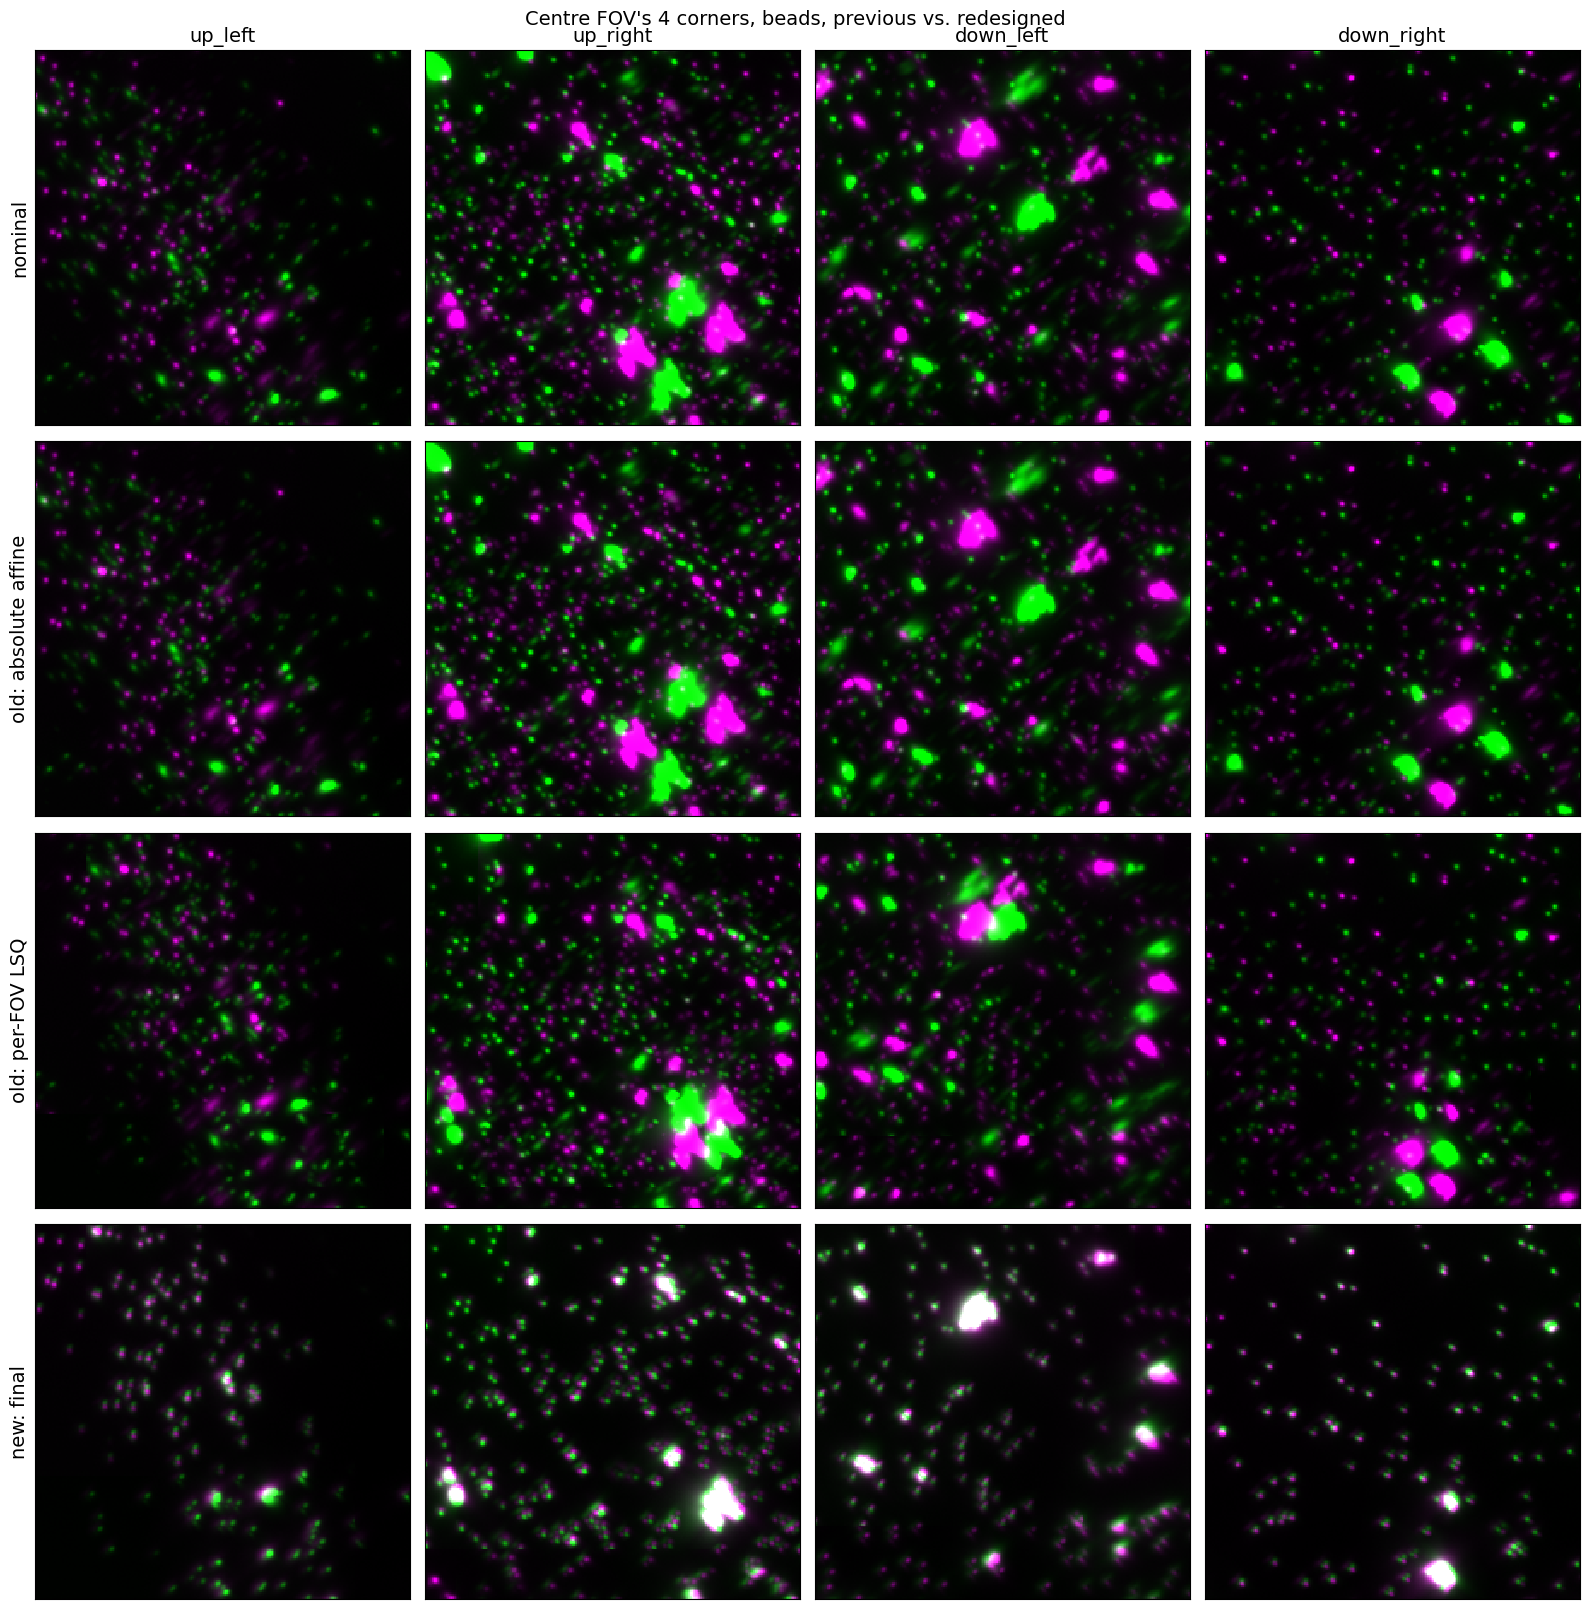

In [7]:
fig = corner_views({"nominal": nominal,
                    "old: absolute affine": methods["old: absolute affine (old edges)"],
                    "old: per-FOV LSQ": methods["old: per-FOV LSQ (old edges)"],
                    "new: final": P_final})
fig.suptitle("Centre FOV's 4 corners, beads, previous vs. redesigned", fontsize=TITLE_FS)
fig.tight_layout(); save(fig, "nbhd_corners_old_vs_new")

saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_06_vs_previous/grid_image_pearson_old_vs_new.png


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_06_vs_previous/image_pearson_cdf.png


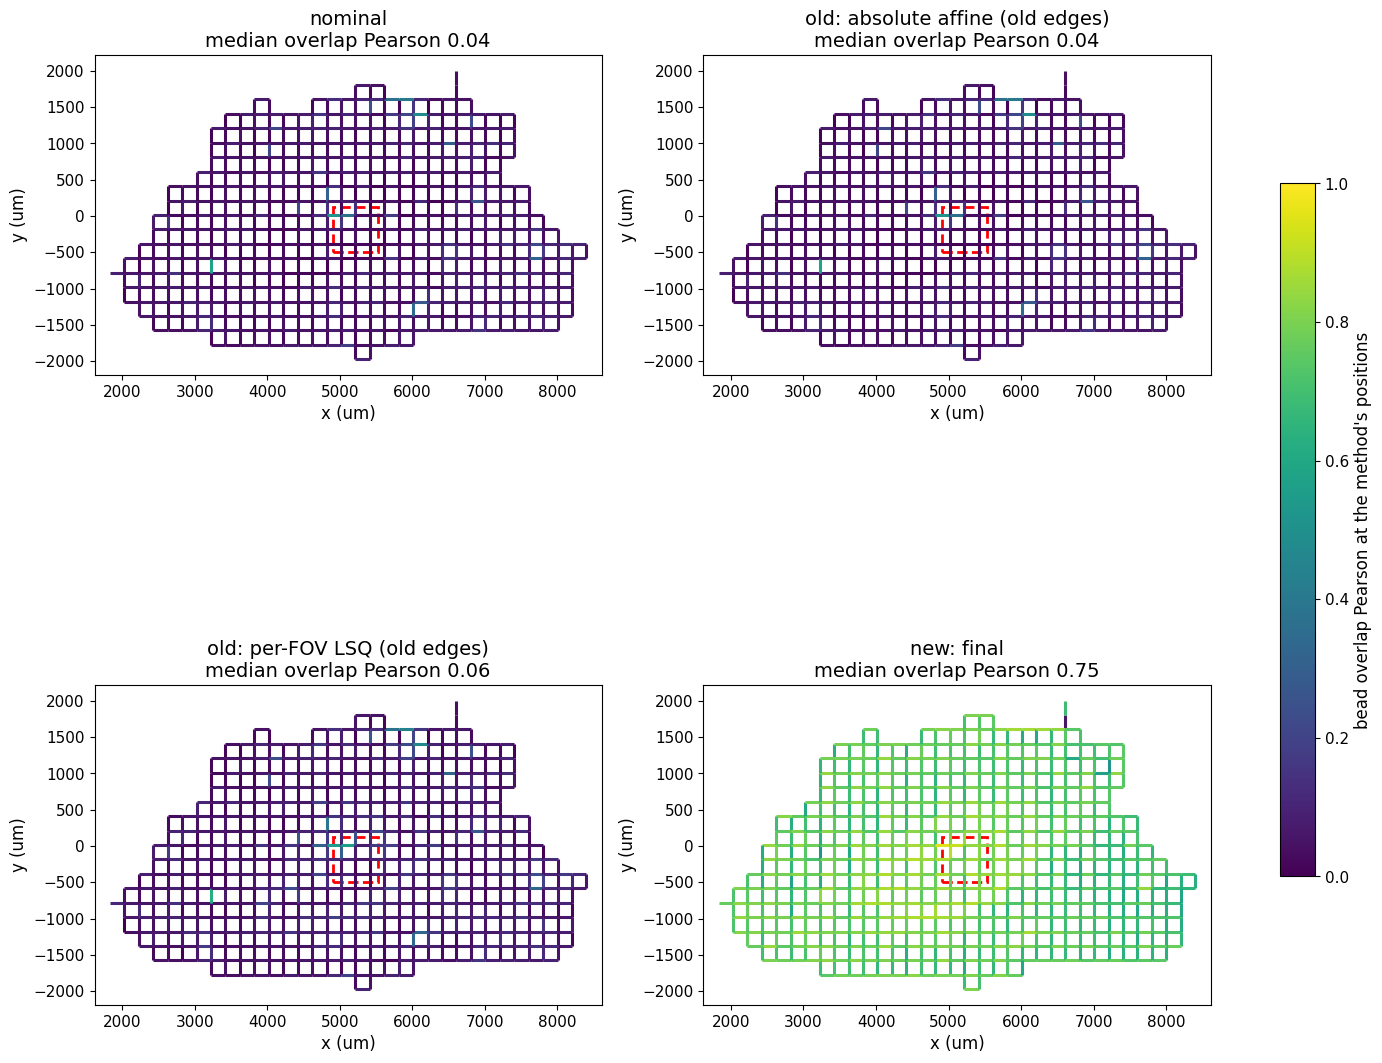

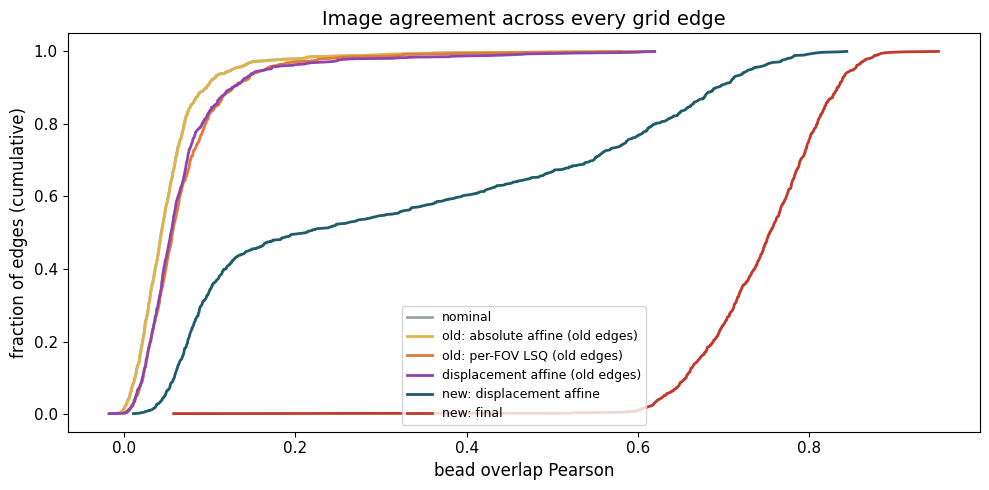

In [8]:
show = ["nominal", "old: absolute affine (old edges)", "old: per-FOV LSQ (old edges)", "new: final"]
fig, ax = plt.subplots(2, 2, figsize=(18, 15))
for a, m in zip(ax.ravel(), show):
    lc = draw_edges(a, nominal, np.arange(len(img)), img[m], "viridis", 0, 1, lw=2.2)
    mark_nbhd(a, nominal, "r")
    a.set_title(f"{m}\nmedian overlap Pearson {img[m].median():.2f}"); a.set_xlabel("x (um)"); a.set_ylabel("y (um)")
fig.colorbar(lc, ax=ax, label="bead overlap Pearson at the method's positions", shrink=0.6)
save(fig, "grid_image_pearson_old_vs_new")
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#9aa5a2", "#e0b44c", "#e07b39", "#8e44ad", "#1d5c68", "#c0392b"]
for m, c in zip(methods, colors):
    v = np.sort(img[m]); ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=c, lw=2, label=m)
ax.set_xlabel("bead overlap Pearson"); ax.set_ylabel("fraction of edges (cumulative)")
ax.set_title("Image agreement across every grid edge"); ax.legend(fontsize=9)
fig.tight_layout(); save(fig, "image_pearson_cdf")

## Notes (numbers quoted by the HTML)

- Old absolute affine: rotation -0.0073 deg, singular values 1.00010/0.99998.
- Displacement affine on the OLD edges: -0.9442 deg, 1.00598/1.00466. New A: -0.9455 deg, 1.01521/1.01385.
- Image overlap Pearson over 894 edges, median / mean / fraction > 0.5:
  nominal 0.043 / 0.053 / 0.002; old absolute affine 0.043 / 0.053 / 0.002;
  old per-FOV LSQ 0.057 / 0.070 / 0.003; displacement affine on old edges 0.055 / 0.071 / 0.007;
  new displacement affine 0.212 / 0.321 / 0.332; new final 0.754 / 0.748 / 0.999.